## 1. About the Question and Objective

**The Problem:**
We are analyzing a nonlinear first-order ordinary differential equation given by:

$$\frac{dx}{dt} = ax^2 - bx^3$$

with an initial condition $x(0) = \delta$, where $\delta$ is a small positive quantity. For this specific experiment, we will set the parameters to $a = 1$ and $b = 1$.

**Tasks:**
1. **Numerical Integration:** Integrate the equation from $t = 0$ to $t = \frac{1.5}{\delta}$ for three different initial conditions: $\delta = 0.1, 0.01$, and $0.001$.
2. **Step Size Analysis:** Observe the expected sharp increase in the solution around $t \sim \delta^{-1}$. We must determine if decreasing $\delta$ requires a correspondingly smaller step size to maintain a smooth numerical solution, and explain why.
3. **Theoretical Explanation:** Investigate the underlying mathematical reason for the sudden increase occurring precisely at $t \sim \delta^{-1}$. To do this, we will compare its behavior with the standard logistic equation ($\dot{x} = ax - bx^2$) to see how the "ramp" region depends on the initial condition $\delta$ in different types of nonlinearities.

**Objective:**
The primary goal is to study the timescale of nonlinear growth phenomena. By comparing this system to the logistic equation, we aim to uncover how the order of the nonlinear term ($x^2$ vs. $x$) dictates how long the system "lingers" near an unstable equilibrium before experiencing rapid growth (a "ramp" or "ignition" phase).

## 2. Mathematical Analysis

**Asymptotic Approximation of the "Ramp" Region:**
For the given equation, $\frac{dx}{dt} = x^2 - x^3$ (with $a=1, b=1$), the initial condition is $x(0) = \delta$, where $\delta$ is very small. 

While $x$ remains small, the $x^3$ term is negligible compared to $x^2$. Therefore, the early dynamics of the system are governed approximately by:

$$\frac{dx}{dt} \approx x^2$$

We can solve this separable differential equation analytically:
$$\int \frac{1}{x^2} dx = \int dt \implies -\frac{1}{x} = t + C$$

Applying the initial condition $x(0) = \delta$:
$$C = -\frac{1}{\delta}$$

Substituting $C$ back in, we get the approximate solution:
$$x(t) \approx \frac{1}{\frac{1}{\delta} - t} = \frac{\delta}{1 - \delta t}$$

**Why the Sudden Increase?**
Looking at the approximate solution $x(t) \approx \frac{\delta}{1 - \delta t}$, we can see a singularity approaching as $t \to \frac{1}{\delta}$. At this time, the denominator approaches zero, causing $x(t)$ to blow up towards infinity. This mathematically explains why the sudden "ramp" or ignition in the solution occurs precisely at $t \sim \delta^{-1}$. As $x$ grows large during this ramp, the $-x^3$ term "wakes up" and arrests the blowup, causing the solution to saturate at $x=1$ (since $\dot{x} = 0$ when $x=1$).

**Comparison with the Logistic Equation:**
Compare this with the logistic equation: $\dot{x} = x - x^2, \ x(0) = \delta$.
Again, for small $x$, the $x^2$ term is negligible, so the early dynamics are:

$$\frac{dx}{dt} \approx x$$

The solution to this is simple exponential growth:
$$x(t) \approx \delta e^t$$

To see a noticeable "ramp" (e.g., reaching an $O(1)$ value like $x \approx 0.5$), we need:
$$e^t \sim \frac{1}{\delta} \implies t \sim \ln\left(\frac{1}{\delta}\right)$$

**Conclusion on Timescales:**
* For the $x^2 - x^3$ system, the ramp time scales as $t \sim \delta^{-1}$.
* For the logistic equation ($x - x^2$), the ramp time scales logarithmically as $t \sim \ln(\delta^{-1})$. 
* Because $x^2$ is a "weaker" instability than $x$ for small values, the $x^2 - x^3$ system lingers near the unstable equilibrium $x=0$ for a much longer time before abruptly jumping.

**Implications for Step Size:**
As $\delta$ decreases (from $0.1$ to $0.001$), the total integration time $t_{end} = \frac{1.5}{\delta}$ increases drastically (from $15$ to $1500$). However, the transition from $x \approx 0$ to $x \approx 1$ happens very abruptly over a narrow time window. If we use the same *number* of points for $\delta=0.001$ as we did for $\delta=0.1$, the absolute step size $h$ becomes enormous. A large step size will entirely miss the narrow, steep gradient of the "ramp," leading to numerical instability or completely inaccurate smooth curves. Therefore, we *must* decrease the relative step size (i.e., significantly increase the number of subdivisions) for smaller $\delta$ to capture the sharp transient behavior smoothly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
def primary_system(t, x):
    return x**2 - x**3

def logistic_system(t, x):
    return x - x**2

In [3]:
deltas = [0.1, 0.01, 0.001]

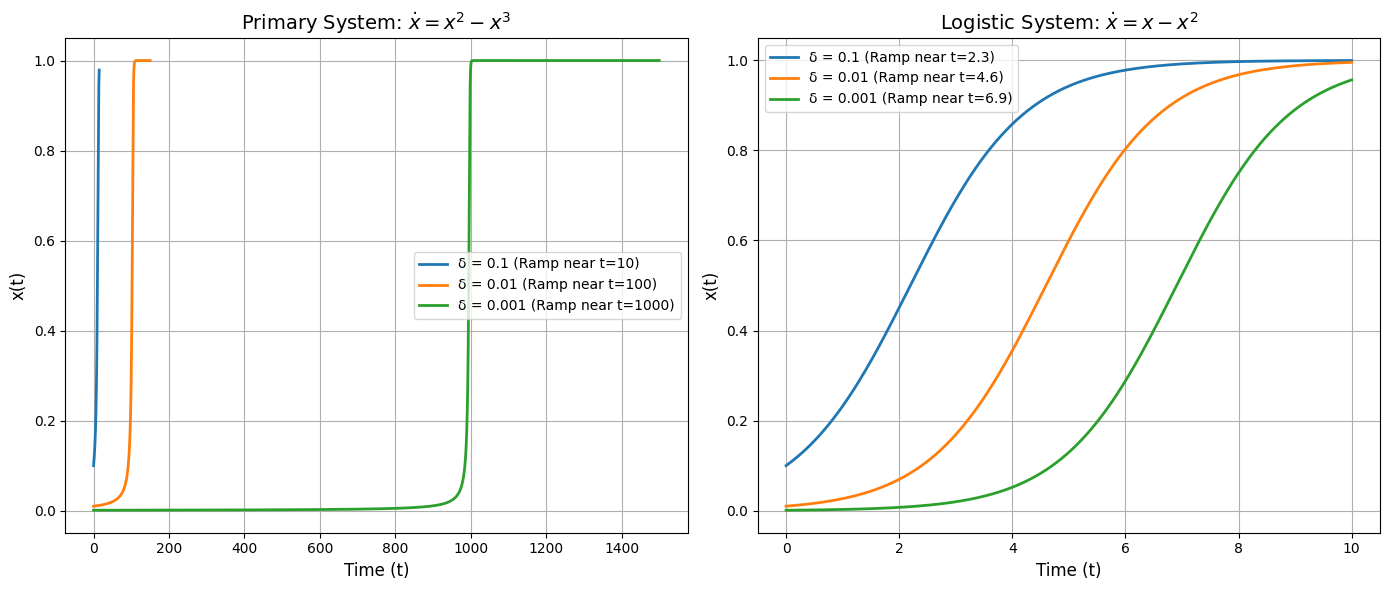

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Primary System (dx/dt = x^2 - x^3) ---
for delta in deltas:
    t_end = 1.5 / delta
    
    # We use a large number of points (5000) for t_eval to ensure the 
    # extremely sharp transition is plotted smoothly. If we used a fixed 
    # small number of points for all deltas, the smaller deltas would look jagged!
    t_eval = np.linspace(0, t_end, 5000) 
    
    # Using LSODA as it handles stiffness and sharp gradients well
    sol = solve_ivp(primary_system, [0, t_end], [delta], t_eval=t_eval, method='LSODA')
    
    axes[0].plot(sol.t, sol.y[0], label=f'δ = {delta} (Ramp near t={1/delta:.0f})', linewidth=2)

axes[0].set_title(r"Primary System: $\dot{x} = x^2 - x^3$", fontsize=14)
axes[0].set_xlabel("Time (t)", fontsize=12)
axes[0].set_ylabel("x(t)", fontsize=12)
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: Logistic System (dx/dt = x - x^2) ---
# For the logistic equation, the ramp happens at t ~ ln(1/delta)
# ln(1/0.001) is approximately 6.9, so integrating up to t=10 is sufficient.
t_end_logistic = 10 

for delta in deltas:
    t_eval = np.linspace(0, t_end_logistic, 1000)
    sol = solve_ivp(logistic_system, [0, t_end_logistic], [delta], t_eval=t_eval, method='LSODA')
    
    # Calculate the theoretical ramp center for the legend
    ramp_center = np.log(1/delta)
    axes[1].plot(sol.t, sol.y[0], label=f'δ = {delta} (Ramp near t={ramp_center:.1f})', linewidth=2)

axes[1].set_title(r"Logistic System: $\dot{x} = x - x^2$", fontsize=14)
axes[1].set_xlabel("Time (t)", fontsize=12)
axes[1].set_ylabel("x(t)", fontsize=12)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. Observation and Conclusion

**Observations from the Simulations:**
* **The "Ramp" Location:** As predicted by our theoretical analysis, the primary system ($\dot{x} = x^2 - x^3$) experiences a sudden, sharp increase from near zero to one. This "ramp" or ignition point shifts further to the right as $\delta$ gets smaller, specifically occurring at $t \approx \delta^{-1}$. For $\delta = 0.001$, the system does nothing for almost 1000 time units before suddenly spiking!
* **Comparison with Logistic Equation:** The logistic system ($\dot{x} = x - x^2$) also exhibits a ramp, but it happens much earlier. For $\delta = 0.001$, the logistic ramp occurs around $t \approx 6.9$ (since $\ln(1000) \approx 6.9$), whereas the primary system takes until $t \approx 1000$. 
* **The Shape of the Transition:** Despite the massive difference in the *time* it takes to trigger the ramp, the actual transition from $x \approx 0$ to $x \approx 1$ happens very rapidly in both systems once it starts.

**Conclusion:**
This exercise demonstrates how the order of a nonlinear term dictates a system's timescale. Because the primary system is dominated by $x^2$ for small $x$, the instability driving it away from the equilibrium $x=0$ is extremely weak initially. It is much weaker than the linear $x$ term in the logistic equation. Consequently, the primary system "lingers" in a quasi-steady state for an $O(\delta^{-1})$ timescale before the instability compounds enough to trigger rapid growth. 

**Answering the Step Size Question:** Yes, we *must* decrease the relative step size (by drastically increasing the number of subdivisions) for each successive, smaller $\delta$. The total integration time scales as $1/\delta$, meaning it becomes very large. However, the width of the "ramp" itself remains relatively narrow and sharp. If we maintain a constant number of data points while increasing the total time domain, the distance between points ($h$) becomes larger than the width of the ramp itself. The numerical solver would step completely over the transition, leading to highly inaccurate results, jagged plots, or failure to capture the saturation at $x=1$. Using a robust solver like `LSODA` with densely evaluated points ensures we accurately capture this stiffness.